[![](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MatthewAlexanderFisher/NCL-MAS3919/blob/main/content/practicals/1-intro-to-pytorch.ipynb)


# Introduction to PyTorch {#sec-practical-intro-pytorch}

## Introduction to Python

Python is a high-level, general-purpose programming language that has become the *de facto* standard for machine learning and data science. Its popularity stems from its readable syntax, extensive ecosystem of libraries, and strong community support.

For this course, we will use Python alongside several key libraries:

- **NumPy** for numerical computing and array operations
- **Matplotlib** for data visualisation
- **PyTorch** for building and training neural networks
- **Pandas** for data manipulation 

### Running Python

There are several ways to run Python code:

1. **Locally** — install Python on your own machine via [Anaconda](https://www.anaconda.com/download) or [Python.org](https://www.python.org/downloads/)
2. **In the cloud** — use a hosted environment like Google Colab (recommended for this course)
3. **On university computers** — Python is pre-installed in the computing labs

### Why Google Colab?

For this course, we recommend using [Google Colab](https://colab.research.google.com/), a free cloud-based Jupyter notebook environment provided by Google. Colab offers several advantages:

- **No installation required** — runs entirely in your browser
- **Free GPU access** — essential for training neural networks efficiently
- **Pre-installed libraries** — NumPy, Matplotlib, PyTorch, and many others are ready to use
- **Google Drive integration** — easily save and share your work
- **Collaboration** — share notebooks like Google Docs

### Getting started with Colab

To run any notebook from this course in Colab:

1. Click the "Open in Colab" badge at the top of the notebook page
2. Sign in with your Google account (university or personal)
3. The notebook will open in a new tab, ready to run

Alternatively, you can upload any `.ipynb` file directly to Colab via **File → Upload notebook**.


### Colab basics

A Colab notebook consists of **cells**, which can be either:

- **Code cells** — contain Python code; run with `Shift+Enter` or the play button
- **Text cells** — contain Markdown for explanations and notes

Some useful keyboard shortcuts:

| Action | Shortcut |
|--------|----------|
| Run cell and move to next | `Shift+Enter` |
| Run cell and stay | `Ctrl+Enter` |
| Insert cell above | `Ctrl+M A` |
| Insert cell below | `Ctrl+M B` |
| Delete cell | `Ctrl+M D` |

### Installing additional packages

Most packages you need are pre-installed, but if you require something else, run:
```python
!pip install package-name
```

The `!` prefix runs shell commands from within a notebook.

### Persistence

Colab sessions are temporary. If your runtime disconnects (after ~90 minutes of inactivity, or ~12 hours maximum), you will need to re-run your cells. Any installed packages or uploaded files will need to be reinstalled/re-uploaded.

To save your work permanently, either:

- **Save to Google Drive** — File → Save a copy in Drive
- **Download the notebook** — File → Download → Download .ipynb


### Enabling GPU acceleration

For notebooks involving neural network training, enable GPU support:

1. Go to **Runtime → Change runtime type**
2. Under "Hardware accelerator", select **GPU** (T4 is typically available for free)
3. Click **Save**

You can verify GPU access by running:


In [ ]:
import torch
print(torch.cuda.is_available())  # Should print True on colab

False


## Introduction to PyTorch

`PyTorch` is an open-source machine learning library developed by Meta AI. It provides two core features:

1. **Tensor computation** with GPU acceleration
2. **Automatic differentiation** for building and training neural networks

### Why PyTorch?

`PyTorch` has become the dominant framework in machine learning research due to its:

- **Pythonic design** — feels natural to Python programmers
- **Dynamic computation graphs** — build and modify models on-the-fly
- **Extensive ecosystem** — libraries for vision, NLP, audio, and more
- **Strong community** — widely used in academia and industry

### Translating mathematics to code

In the notation used in this course, a parameterised model is a family of functions

$$
\mathcal{F} = \{ f_{\boldsymbol{\theta}} \}_{\boldsymbol{\theta}} .
$$

Given a loss function

$$
L\bigl(y, f_{\boldsymbol{\theta}}(\boldsymbol{x})\bigr),
$$

and a dataset $\{(\boldsymbol{x}_i, y_i)\}_{i=1}^n$, we aim to learn parameters $\boldsymbol{\theta}$ that minimise the empirical risk

$$
\mathcal{R}_n(f_{\boldsymbol{\theta}})
= \frac{1}{n} \sum_{i=1}^{n}
L\bigl(y_i, f_{\boldsymbol{\theta}}(\boldsymbol{x}_i)\bigr).
$$

In practice, this optimisation problem almost never admits a closed-form solution and must be solved numerically using an iterative optimisation algorithm.

`PyTorch` provides direct support for each part of this pipeline:

- we define the model $f_{\boldsymbol{\theta}}$ as a Python class
- we define the loss function $L$ as a Python function (or a predefined PyTorch loss)
- we represent the data and parameters using tensors
- we use **automatic differentiation** to compute
  $\nabla_{\boldsymbol{\theta}} \mathcal{R}_n(f_{\boldsymbol{\theta}})$
- we update the parameters using an optimisation algorithm (e.g. stochastic gradient descent)

Conceptually, the correspondence is:

| Mathematical object                         | PyTorch concept                                          |
|---------------------------------------------|----------------------------------------------------------|
| parameters $\boldsymbol{\theta}$            | tensors with `requires_grad=True`                        |
| model $f_{\boldsymbol{\theta}}$             | `nn.Module` with a `forward` method                      |
| loss $L$                                    | loss function                                            |
| gradient $\nabla_{\boldsymbol{\theta}}$     | computed automatically by autograd                       |
| optimiser                                   | object from `torch.optim`                                |

A typical training step in `PyTorch` therefore mirrors the mathematical objective:

1. evaluate the model $f_{\boldsymbol{\theta}}(\boldsymbol{x})$
2. compute the loss $L\bigl(y, f_{\boldsymbol{\theta}}(\boldsymbol{x})\bigr)$
3. compute gradients using automatic differentiation
4. update $\boldsymbol{\theta}$ using an optimiser

This tutorial will show how each of these mathematical components is implemented using `PyTorch`.

### Python Essentials

#### Data Types

In PyTorch work you mainly use:

In [2]:
# numbers
x = 3          # int
y = 3.14       # float

# booleans
flag = True

# lists (ordered, mutable)
xs = [1, 2, 3]

# tuples (ordered, immutable)
shape = (32, 32)

# dictionaries (key–value)
config = {"lr": 1e-3, "batch_size": 64}

#### Packages

Colab always uses imports.

In [3]:
import torch                       # main PyTorch library
import torch.nn as nn              # neural network module
import torch.optim as optim        # optimisation module (e.g. SGD, Adam)
import matplotlib.pyplot as plt    # plotting library   

Alias style is standard:

In [4]:
import numpy as np

Accessing a package:

In [5]:
torch.randn(10)     # accessing torch
np.random.rand(10)  # accessing numpy using its alias

array([0.41922027, 0.59238886, 0.83599607, 0.9325504 , 0.31021581,
       0.84021006, 0.40692659, 0.90587577, 0.02879064, 0.20226762])

#### Function Syntax

In [6]:
def square(x):
    return x * x

print(square(5))  # Should print 25

25


In `PyTorch`, functions are mainly used to:

- define the forward computation of a model

- define loss functions or evaluation metrics

- wrap parts of the training logic

The most important example is a model’s **forward** function:

In [7]:
def forward(self, x):
    return self.linear(x)

#### Loops

In PyTorch, loops are mainly used to iterate over data and training steps.

**for-loop**

In [8]:
for i in range(5):
    print(i)

0
1
2
3
4


In this module, we typically perform a for-loop over training data. E.g.

In [ ]:
for x, y in dataloader:
    ...

**while-loop**

This is much rarer in `PyTorch` tutorials, but can be used when training is driven by a convergence or stopping criterion rather than a fixed number of epochs, for example:

In [ ]:
while loss > tol:
    ...

#### Classes

In Python, a class is used to bundle data and behaviour into a single object.

In other words, a class defines:

- what data an object stores

- what operations (methods) can be applied to it

Minimal example:

In [9]:
class Counter:

    def __init__(self, value=0):
        self.value = value

    def step(self):
        self.value += 1

Minimal usage:

In [10]:
c = Counter()
c.step()
print(c.value)

1


In [11]:
c.step()
print(c.value)

2


Essential ideas:

- `__init__` is called when the object is created

- `self` refers to the current object

- attributes are created as `self.something`

- methods are just functions that belong to the class


In `PyTorch`, a **model** is implemented as a class:

- parameters (layers, tensors) are stored as attributes

- the forward computation is defined as a method

A model is a Python class that inherits from `nn.Module`.

In [13]:
import torch.nn as nn

class Net(nn.Module):

    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(10, 1)

    def forward(self, x):
        return self.linear(x)


Usage:

In [ ]:
model = Net()
y = model(x)   # calls forward internally

If a layer or parameter is not assigned to `self`, `PyTorch` will not register it and it will not be trained.

### Tensors

The fundamental data structure in PyTorch is the **tensor** — a multi-dimensional array, analogous to a NumPy array, but with built-in support for GPU acceleration and automatic differentiation.

In practice, you should think of a PyTorch tensor in exactly the same way as a NumPy array.

#### Creating tensors

From Python lists:

In [14]:
x = torch.tensor([1.0, 2.0, 3.0])

From nested lists (matrices):

In [38]:
A = torch.tensor([[1.0, 2.0],
                  [3.0, 4.0]]) # shape (2, 2) - a tensor of rank 2 (a matrix)

B = torch.tensor([[[1.0, 2.0],
                  [3.0, 4.0]],
                  [[4.0, 6.0],
                  [8.0, 10.0]]]) # shape (2, 2, 2) - a tensor of rank 3 (a batch of matrices)

Common initialisation routines (identical in spirit to `NumPy`):

In [16]:
x = torch.zeros(5)
y = torch.ones(3, 4)
z = torch.randn(10)      # standard normal
A = torch.eye(3)         # identity matrix

print(z)

tensor([-0.5045,  0.5377,  1.8033, -0.8882, -1.4724,  0.6881,  0.3404, -0.2323,
        -0.5028, -0.3703])


From a `NumPy` array:

In [23]:
import numpy as np

a = np.array([1, 2, 3])
x = torch.from_numpy(a)

print(x)

tensor([1, 2, 3])


Like NumPy, tensors have a shape and a dtype:

In [24]:
x.shape
print(x.shape)

x.dtype
print(x.dtype)

torch.Size([3])
torch.int64


#### Basic operations

Just like in `NumPy`, or `R`, operations on `PyTorch` tensors are vectorised:


In [25]:
x = torch.randn(5)
y = torch.randn(5)

print(x)
print(y)

x + y
x - y
x * y
x / y

print(x + y)

tensor([-0.1204, -0.0931,  0.8892, -2.5780,  1.4815])
tensor([-0.1331, -0.8201,  1.1084, -1.3394, -0.7245])
tensor([-0.2535, -0.9131,  1.9975, -3.9175,  0.7570])


Scalar operations:

In [26]:
2.0 * x
x + 1.0

print(x + 1.0)

tensor([ 0.8796,  0.9069,  1.8892, -1.5780,  2.4815])


#### Matrix and vector operations

Matrix multiplication uses standard syntax conventions:

In [27]:
A = torch.randn(3, 4)
B = torch.randn(4, 2)

A @ B

tensor([[ 2.4568, -1.7753],
        [ 0.1665,  1.0247],
        [ 2.5644, -0.6532]])

Alternatively, a `PyTorch` specific way:

In [28]:
torch.matmul(A, B)

tensor([[ 2.4568, -1.7753],
        [ 0.1665,  1.0247],
        [ 2.5644, -0.6532]])

#### Indexing and slicing

Indexing is identical to `NumPy`:


In [29]:
x = torch.randn(10)

x[0]
x[2:5]

tensor([ 1.8608,  0.7837, -1.5691])

For matrices:

In [32]:
A

tensor([[ 0.7410, -2.2633,  0.9737, -1.5928,  1.0176],
        [-0.4862,  0.1618,  1.7191,  0.3324,  0.8171],
        [-1.4192, -0.0439, -0.7170,  0.4882, -0.5204],
        [ 0.6129,  2.0961,  0.4827, -0.9906,  0.2413]])

In [34]:
A[0,1]

tensor(-2.2633)

In [46]:
A = torch.randn(4, 5)
print("A: \n", A)


A[0, :]
print("A[0, :]: \n", A[0, :])

A[:, 1]
print("A[:, 1]: \n", A[:, 1])

A[1:3, 2:4]
print("A[1:3, 2:4]: \n", A[1:3, 2:4])

A: 
 tensor([[-1.2290,  1.2304,  0.5908,  0.3963,  1.7227],
        [ 1.1357, -0.7388,  1.3623,  0.0674,  0.2522],
        [-0.1132, -0.9760,  0.3622, -0.5417,  0.3468],
        [ 1.2598, -1.4888,  0.6890,  0.8857, -0.7124]])
A[0, :]: 
 tensor([-1.2290,  1.2304,  0.5908,  0.3963,  1.7227])
A[:, 1]: 
 tensor([ 1.2304, -0.7388, -0.9760, -1.4888])
A[1:3, 2:4]: 
 tensor([[ 1.3623,  0.0674],
        [ 0.3622, -0.5417]])


#### Reshaping

As in `NumPy`, reshaping does not copy data when possible:

In [50]:
x = torch.randn(12)

y = x.reshape(3, 4)
print("y: \n", y)

y: 
 tensor([[ 0.9511, -0.5623,  1.1876, -2.6156],
        [ 0.0402, -0.2292,  0.7698, -0.9850],
        [ 0.3796, -1.2254,  0.1966,  0.2785]])


Flattening:

In [48]:
y.flatten()

tensor([ 0.4699, -0.4635,  1.4447,  0.4703, -0.6972,  1.8570, -0.7516,  0.0500,
         1.2351,  0.5524,  0.3220,  0.2093])

#### Reductions along a dimension

These reduction operations may also *reduce* a tensor by collapsing one dimension.

The most common examples are `sum`, `mean`, `max`, etc.

In `PyTorch`, the argument

```python
dim = k
```

means reduce along axis `k` (collapse that axis).

**Example: a 2-D tensor**

In [54]:
A = torch.tensor([[1., 2., 3.],
                  [4., 5., 6.]])

print("A: \n", A)

A: 
 tensor([[1., 2., 3.],
        [4., 5., 6.]])


Its shape is

In [ ]:
A.shape    # [2, 3]

torch.Size([2, 3])

Think of the dimensions as:

- dimension 0 → rows
- dimension 1 → columns

There are three options of reducing here:

**No dimension specified**

In [53]:
A.sum()

tensor(21.)

All entries are summed and a single scalar is returned.

---

**Reducing along `dim=0`**

In [58]:
A.sum(dim=0) # tensor([5., 7., 9.])

tensor([5., 7., 9.])

Here:

- we collapse dimension 0 (the rows)

- we keep dimension 1 (the columns)

So each output entry is the sum *down the rows*:

$$
\begin{bmatrix}
1 & 2 & 3 \\
4 & 5 & 6
\end{bmatrix}
 \xrightarrow{\text{sum over dim 1}}
\begin{bmatrix}
1+4, 2+5, 3+6
\end{bmatrix}
$$

The output shape is:

In [ ]:
A.sum(dim=0).shape   # [3]

torch.Size([3])

**Reducing along `dim=1`**

In [61]:
A.mean(dim=1) # tensor([2., 5.])

tensor([2., 5.])

Here:

* we collapse dimension 1 (the columns)
* we keep dimension 0 (the rows)

So each output entry is the sum across each row:

$$
\begin{bmatrix}
1 & 2 & 3 \\
4 & 5 & 6
\end{bmatrix}
 \xrightarrow{\text{sum over dim 1}}
\begin{bmatrix}
1+2+3,4+5+6
\end{bmatrix}
$$

The output shape is:

In [ ]:
A.mean(dim=1).shape # [2]

torch.Size([2])

#### Automatic Differentiation

The key element that is **new to `PyTorch`**, and that you are unlikely to have seen before, is **automatic differentiation**.

In essence, we are allowed to treat complicated numerical code as a *differentiable mathematical function* and ask `PyTorch` to compute its derivatives for us automatically.

More precisely, suppose we define a scalar-valued function

$$
F(\boldsymbol{\theta}) \in \mathbb{R}
$$

using `PyTorch` tensor operations.  

If the tensor $\boldsymbol{\theta}$ is marked as requiring gradients, `PyTorch` can compute

$$
\nabla_{\boldsymbol{\theta}} F(\boldsymbol{\theta})
$$

exactly (up to floating-point error), using the chain rule.

---

##### A simple example

Consider the function

$$
F(\theta) = \theta^2 + 3\theta.
$$

We can implement this directly in `PyTorch`:



In [63]:
import torch

theta = torch.tensor(2.0, requires_grad=True)

F = theta ** 2 + 3 * theta


To compute the derivative, we call:

In [64]:
F.backward()

The gradient is stored in:

In [65]:
theta.grad

tensor(7.)

which gives, since $\theta = 2$,
$$
\frac{dF}{d\theta} = 2\theta + 3 = 2 \times 2 + 3 = 7
$$

##### A slightly more realistic example

Let us define a small function using several operations:

In [66]:
def f(theta):
    return (theta**2).sum() + torch.sin(theta).sum()

Now evaluate it at a vector:

In [70]:
theta = torch.randn(5, requires_grad=True)
loss = f(theta)

print("loss: \n", loss)

loss: 
 tensor(4.2859, grad_fn=<AddBackward0>)


Since `loss` is a scalar, we can compute its gradient with respect to `theta`:

In [68]:
loss.backward()

The result is:

In [69]:
theta.grad

tensor([ 0.3924, -0.2850,  3.2652, -4.4237,  1.9403])

which contains
$$
\nabla_{\bm{\theta}} f(\bm{\theta}).
$$

##### Why the output must be a scalar

`PyTorch`’s automatic differentiation computes gradients of scalar outputs with respect to tensors.

In machine learning, this scalar is typically the empirical risk:
$$
\mathcal{R}_n(f_{\bm{\theta}}),
$$
where we wish to compute $\nabla_{\bm{\theta}} \mathcal{R}_n(f_{\bm{\theta}})$.


##### Key Syntax

In order to use `PyTorch`'s automatic differentiation abilities, you must specify the tensor as `requires_grad=True`

That is, the following code will work:

In [71]:
x = torch.tensor(2.0, requires_grad=True)
f = x ** 2 + 3 * x
f.backward()
x.grad

tensor(7.)

The following will not:

In [ ]:
x = torch.tensor(2.0) # requires_grad=False is the default
f = x ** 2 + 3 * x
f.backward()
x.grad # RunTime error

## Implementing a Linear Model in `PyTorch`

### Defining the Model

We will use the polynomial regression model

$$
f_{\boldsymbol{\theta}}(x)
= \theta_0 + \theta_1 x + \theta_2 x^2 + \theta_3 x^3 + \theta_4 x^4,
$$

where $\boldsymbol{\theta} = (\theta_0,\theta_1,\theta_2,\theta_3,\theta_4)$ are the learnable parameters.

In `PyTorch`, models are implemented as classes that inherit from `nn.Module`. 

The key method is `forward`, which defines **how inputs are mapped to outputs**, i.e. it implements the function $f_{\boldsymbol{\theta}}$.


When you write

```python
y_hat = model(x)
```

`PyTorch` automatically calls

```python
y_hat = model.forward(x)
```

(plus some internal bookkeeping). This is why we always implement forward rather than calling it directly.

#### Model code

A convenient way to implement this model is to store the coefficients as learnable parameters and build the polynomial features inside forward.

In [73]:
import torch
import torch.nn as nn

class Poly4(nn.Module):
    def __init__(self):
        super().__init__()
        # five learnable coefficients: theta_0, ..., theta_4
        self.theta = nn.Parameter(torch.zeros(5)) # default values

    def forward(self, x):
        """
        x: tensor of shape (n,) or (n, 1)
        returns: tensor of predictions, same shape as x (flattened to (n,))
        """
        x = x.reshape(-1)  # ensure shape (n,)
        # build [1, x, x^2, x^3, x^4] for each data point
        X = torch.stack([torch.ones_like(x), x, x**2, x**3, x**4], dim=1)  # (n, 5)
        return X @ self.theta  # (n,)


A quick sanity check:

In [74]:
model = Poly4()
x = torch.tensor([0.0, 1.0, 2.0])
y_hat = model(x)
y_hat

tensor([0., 0., 0.], grad_fn=<MvBackward0>)

### What `forward` is doing (math to code)

For input values $x_1,\dots,x_n$, define the design matrix

$$
X =
\begin{bmatrix}
1 & x_1 & x_1^2 & x_1^3 & x_1^4 \\
1 & x_2 & x_2^2 & x_2^3 & x_2^4 \\
\vdots & \vdots & \vdots & \vdots & \vdots \\
1 & x_n & x_n^2 & x_n^3 & x_n^4
\end{bmatrix}
\in \mathbb{R}^{n \times 5}.
$$

Then the model predictions are

$$
\hat{\boldsymbol{y}} = X \boldsymbol{\theta}.
$$

That is exactly what this line computes:

```python
return X @ self.theta
```

### Training on Synthetic Data (will go into more detail next time)


We now generate a small synthetic dataset from a known polynomial and fit the model defined
above.  
We will *not* discuss the optimisation details yet – this is only to show the full pipeline
working end-to-end.


#### Generate synthetic data




In [84]:
import torch

torch.manual_seed(0)

# ground-truth coefficients (theta_0 ... theta_4)
true_theta = torch.tensor([1.0, -2.0, 0.5, 0.3, -0.01])

def true_function(x):
    X = torch.stack(
        [torch.ones_like(x), x, x**2, x**3, x**4],
        dim=1
    )
    return X @ true_theta

# training inputs
n = 80
x_train = torch.linspace(-4, 4, n)

# noisy observations
y_train = true_function(x) + 0.2 * torch.randn(n)

Plotting:

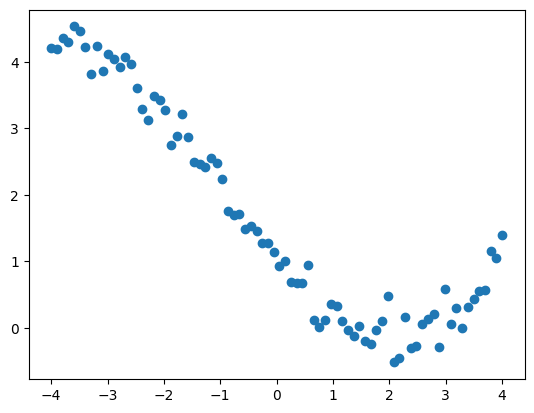

In [85]:
import matplotlib.pyplot as plt

plt.plot(x_train, y_train, 'o', label='data')

#### Train the model

In [91]:
model = Poly4()

loss_fn = torch.nn.MSELoss() # mean squared error loss
optimizer = torch.optim.Adam(model.parameters(), lr=0.05)  # Adam optimiser with learning rate 0.05 - a form of SGD with momentum and adaptive learning rates

losses = []

for _ in range(100):

    optimizer.zero_grad()

    y_hat = model(x_train)
    loss = loss_fn(y_hat, y_train)

    loss.backward()
    optimizer.step()

    losses.append(loss.item())


#### Plot the fitted curve

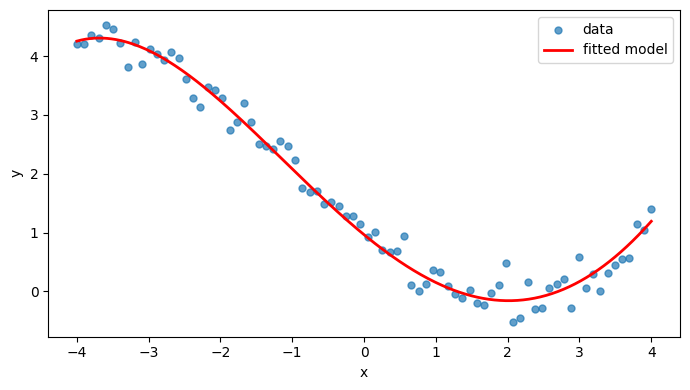

In [92]:
import matplotlib.pyplot as plt

# dense grid for a smooth curve
x_plot = torch.linspace(-4, 4, 400)

with torch.no_grad():
    y_pred = model(x_plot)

plt.figure(figsize=(7, 4))
plt.scatter(x_train.numpy(), y_train.numpy(), s=25, alpha=0.7, label="data")
plt.plot(x_plot.numpy(), y_pred.numpy(), color='red', linewidth=2, label="fitted model")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.tight_layout()
plt.show()


Plot loss over time:

Text(0, 0.5, 'Loss')

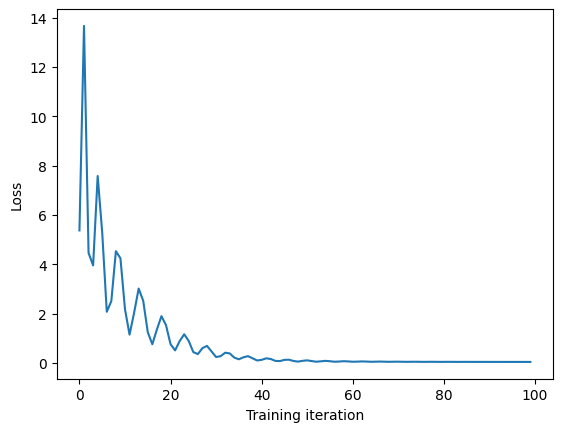

In [94]:
plt.plot(losses)
plt.xlabel("Training iteration")
plt.ylabel("Loss")